<a href="https://colab.research.google.com/github/MithilSave/Cyber-Threat-Intelligence-Dashboard/blob/main/Brain_Tumor_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Brain_Tumor_Detection.ipynb

Automatically generated by Colab.

This notebook walks through the process of building a Convolutional Neural Network (CNN)
to classify brain MRI scans as either containing a tumor or not.


# Step 1: Import all the necessary libraries


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# No longer need zipfile

# Step 2: Download Dataset using KaggleHub


In [ ]:
!pip install -q kagglehub

Import the kagglehub library

In [ ]:
import kagglehub

#Download the dataset. It will be cached locally.
This returns the path to the downloaded dataset directory.


In [ ]:
print("Downloading dataset from KaggleHub...")
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")
print(f"Dataset downloaded to: {path}")

# Define the path to the actual image folders
data_dir = os.path.join(path, "brain_tumor_dataset")

# Verify the path and its contents
print("\nChecking contents of the dataset directory...")
try:
    print("Classes found:", os.listdir(data_dir)) # should show ['yes', 'no']
except FileNotFoundError:
    print(f"Error: The directory '{data_dir}' was not found.")
    print("Please check the dataset structure on Kaggle if this error persists.")


Dataset downloaded to: /kaggle/input/brain-mri-images-for-brain-tumor-detection

Checking contents of the dataset directory...
Classes found: ['no', 'yes']


# Step 3: Load and Preprocess the Data

In [ ]:
# The `data_dir` is now defined in Step 2 from the KaggleHub download path.
categories = ['no', 'yes']
IMG_SIZE = 150 # We will resize all images to 150x150

# Create a list to hold the image data and corresponding labels
data = []
labels = []

print("\nLoading and preprocessing images...")

# Loop through the 'no' and 'yes' categories
for i, category in enumerate(categories):
    # Construct the path to the category folder (e.g., '.../brain_tumor_dataset/yes')
    category_path = os.path.join(data_dir, category)
    if not os.path.isdir(category_path):
        print(f"Error: Directory not found at {category_path}")
        break

    for img_name in os.listdir(category_path):
        try:
            # Construct the full image path
            img_path = os.path.join(category_path, img_name)
            # Read the image in grayscale using OpenCV
            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            # Resize the image to our standard size
            resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            # Append the resized image and its label (0 for 'no', 1 for 'yes')
            data.append(resized_array)
            labels.append(i)
        except Exception as e:
            print(f"Error loading image {img_name}: {e}")

print(f"Finished loading. Total images: {len(data)}")

# Convert the lists to NumPy arrays for efficient processing
# Also, normalize the pixel values to be between 0 and 1
data = np.array(data) / 255.0
labels = np.array(labels)

# Reshape the data to include a channel dimension (required for CNN)
# For grayscale, the channel dimension is 1
data = data.reshape(-1, IMG_SIZE, IMG_SIZE, 1)


Loading and preprocessing images...
Finished loading. Total images: 253


#Step 4: Split the Data into Training and Testing Sets

In [ ]:
# We'll use an 80/20 split. 80% for training, 20% for testing.
# `stratify=labels` ensures that the proportion of 'yes' and 'no' is the same in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")


Training data shape: (202, 150, 150, 1)
Testing data shape: (51, 150, 150, 1)
Training labels shape: (202,)
Testing labels shape: (51,)


# Step 5: Build the Convolutional Neural Network (CNN)

In [ ]:
model = keras.models.Sequential([
    # First Convolutional Block
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    keras.layers.MaxPooling2D(2, 2),

    # Second Convolutional Block
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),

    # Third Convolutional Block
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),

    # Flatten the results to feed into a dense layer
    keras.layers.Flatten(),

    # Dense Layer for classification
    keras.layers.Dense(512, activation='relu'),

    # Dropout layer to prevent overfitting
    keras.layers.Dropout(0.5),

    # Output Layer
    # Single neuron with sigmoid activation for binary classification (yes/no)
    keras.layers.Dense(1, activation='sigmoid')
])

# Print a summary of the model's architecture
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,033,601 (72.61 MB)

 Trainable params: 19,033,601 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

# Step 6: Compile and Train the Model

In [ ]:
# Compile the model with an optimizer, loss function, and metrics to track
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
# `epochs` is the number of times the model will see the entire training dataset.
# `validation_data` is used to check the model's performance on unseen data during training.
print("\nStarting model training...")
history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_test, y_test))
print("Model training finished.")


Starting model training...
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6134 - loss: 0.9266 - val_accuracy: 0.7451 - val_loss: 0.6040
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7844 - loss: 0.5137 - val_accuracy: 0.7255 - val_loss: 0.7025
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7705 - loss: 0.4678 - val_accuracy: 0.7451 - val_loss: 0.5781
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8356 - loss: 0.4363 - val_accuracy: 0.7255 - val_loss: 0.6161
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7839 - loss: 0.3969 - val_accuracy: 0.7647 - val_loss: 0.6386
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8625 - loss: 0.3267 - val_accuracy: 0.7843 - val_loss: 0.6066
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8477 - loss: 0.3161 - val_accuracy: 0.7647 - val_loss: 0.5907
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8879 - loss: 0.2651 - val_accuracy: 0.7647

# Step 7: Evaluate the Model's Performance

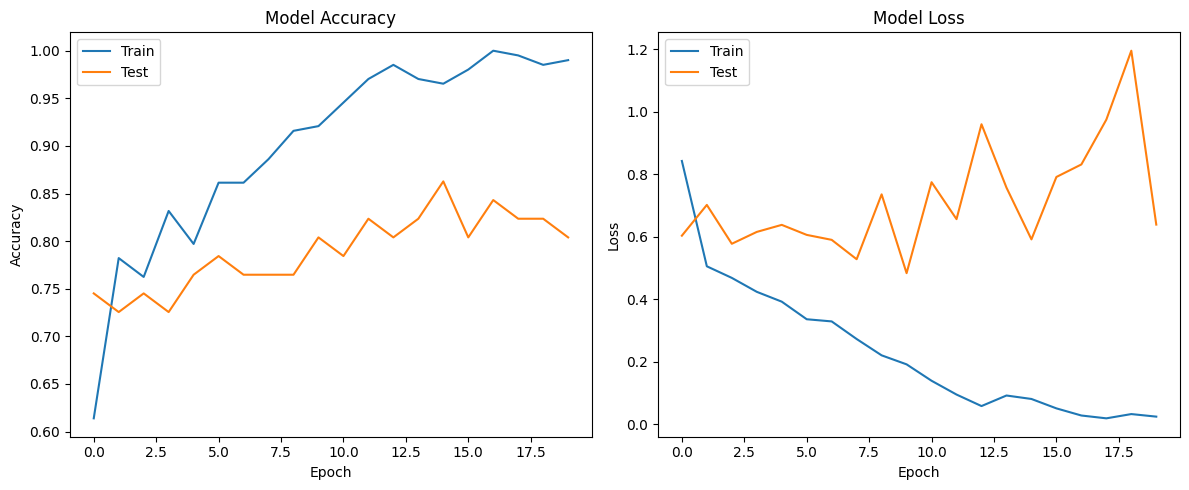

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step

Classification Report:
              precision    recall  f1-score   support

          no       0.81      0.65      0.72        20
         yes       0.80      0.90      0.85        31

    accuracy                           0.80        51
   macro avg       0.81      0.78      0.79        51
weighted avg       0.80      0.80      0.80        51



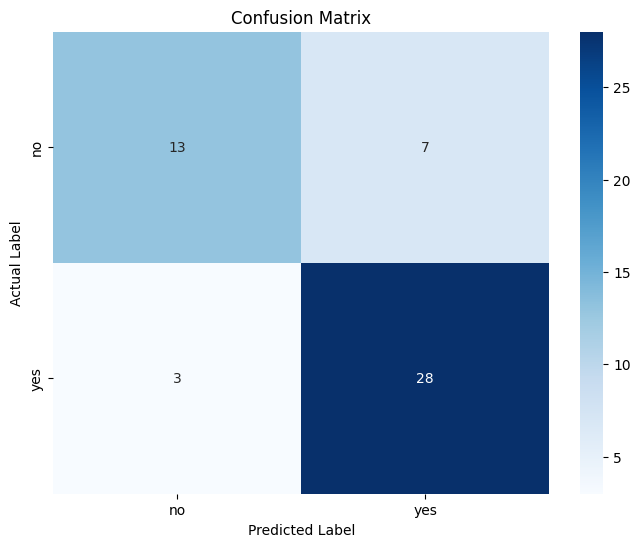

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.tight_layout()
plt.show()

# Make predictions on the test set
predictions = model.predict(X_test)
# The output of the sigmoid function is a probability.
# We'll classify anything with a probability > 0.5 as 'yes' (1) and <= 0.5 as 'no' (0).
predicted_classes = (predictions > 0.5).astype(int).flatten()

# Generate the Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predicted_classes, target_names=categories))

# Generate and Plot the Confusion Matrix
cm = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Step 8: Test the Model on a Single Image

In [ ]:
def predict_single_image(image_path):
    """Loads an image, preprocesses it, and predicts the class."""
    try:
        # Load and preprocess the image in the same way as the training data
        img_array = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
        normalized_array = resized_array / 255.0
        # Reshape to (1, IMG_SIZE, IMG_SIZE, 1) to represent a single sample
        reshaped_array = normalized_array.reshape(1, IMG_SIZE, IMG_SIZE, 1)

        # Make prediction
        prediction = model.predict(reshaped_array)

        # Display the image
        plt.imshow(resized_array, cmap='gray')
        plt.axis('off')

        # Interpret and print the result
        if prediction[0][0] > 0.5:
            plt.title(f"Prediction: Tumor (Confidence: {prediction[0][0]:.2%})")
        else:
            plt.title(f"Prediction: No Tumor (Confidence: {1-prediction[0][0]:.2%})")

        plt.show()

    except Exception as e:
        print(f"Could not process image at {image_path}. Error: {e}")

Example usage: Find one 'yes' and one
'no' image from the test set to predict
*   NOTE: This part assumes your dataset structure is intact.
*   We'll find the first image in the test set that is 'yes' and the first that is 'no'.




--- Prediction on an image WITH a tumor ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


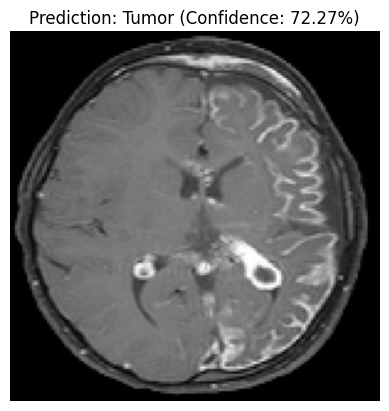


--- Prediction on an image WITHOUT a tumor ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


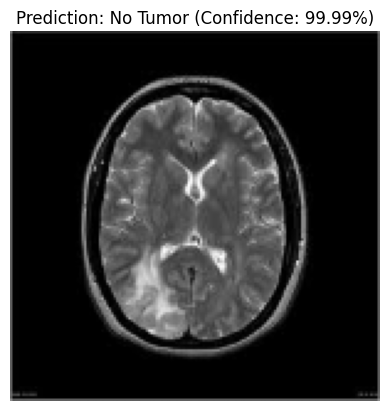

In [ ]:
try:
    yes_image_index = np.where(y_test == 1)[0][0]
    no_image_index = np.where(y_test == 0)[0][0]

    # To simulate a real file path, we need to find its original location.
    # This is a bit complex, so for demonstration, we'll just use the array data.
    # A real application would use a file path like:
    # predict_single_image('path/to/your/image.jpg')

    print("\n--- Prediction on an image WITH a tumor ---")
    test_image_yes = X_test[yes_image_index].reshape(1, IMG_SIZE, IMG_SIZE, 1)
    prediction = model.predict(test_image_yes)
    plt.imshow(X_test[yes_image_index].squeeze(), cmap='gray')
    plt.title(f"Prediction: Tumor (Confidence: {prediction[0][0]:.2%})")
    plt.axis('off')
    plt.show()

    print("\n--- Prediction on an image WITHOUT a tumor ---")
    test_image_no = X_test[no_image_index].reshape(1, IMG_SIZE, IMG_SIZE, 1)
    prediction = model.predict(test_image_no)
    plt.imshow(X_test[no_image_index].squeeze(), cmap='gray')
    plt.title(f"Prediction: No Tumor (Confidence: {1-prediction[0][0]:.2%})")
    plt.axis('off')
    plt.show()

except IndexError:
    print("\nCould not find a 'yes' or 'no' sample in the test set for the final prediction demo.")
except Exception as e:
    print(f"An error occurred during the final prediction demo: {e}")

# Step 9: Predict on a User-Uploaded Image

Please upload an MRI image to test the model.


Saving test1_img.jpeg to test1_img.jpeg

User uploaded file: test1_img.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


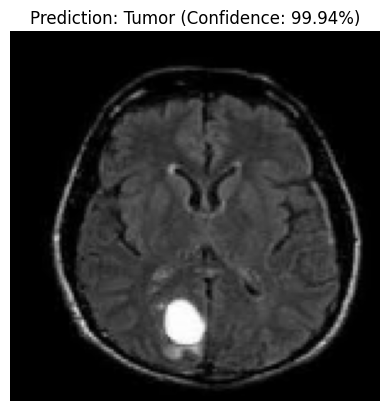

In [ ]:
# This cell allows you to upload your own MRI image and see the model's prediction.
# Import the files module from google.colab to handle file uploads
from google.colab import files

print("Please upload an MRI image to test the model.")
# Prompt the user to upload a file. This will open a file dialog in your browser.
uploaded = files.upload()

# Check if a file was uploaded by checking if the 'uploaded' dictionary is not empty
if len(uploaded.keys()) > 0:
    # Get the filename of the uploaded image (we'll just use the first one)
    file_name = next(iter(uploaded))
    print(f"\nUser uploaded file: {file_name}")

    # The uploaded file's content is in memory. To use it with OpenCV's imread,
    # which requires a file path, we first save the file to the Colab environment.
    with open(file_name, 'wb') as f:
        f.write(uploaded[file_name])

    # Now, call our existing prediction function with the path to the newly saved image.
    # The function will handle preprocessing, prediction, and displaying the result.
    predict_single_image(file_name)

else:
    print("\nNo file was uploaded.")
